In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV. Since the CSV is one folder up from 'notebooks', we use '../'
df = pd.read_csv('../Fraudulent_E-Commerce_Transaction_Data.csv')

# Look at the first 5 rows
print("Detective, here are your first 5 clues:")
display(df.head())

# Check the 'Answer Key' - how many are actually fraud?
print("\nFraudulent (1) vs. Legitimate (0) counts:")
print(df['Is Fraudulent'].value_counts())

ModuleNotFoundError: No module named 'pandas'

In [1]:
import pandas as pd
# Load the file directly from the main folder
df = pd.read_csv('../Fraudulent_E-Commerce_Transaction_Data.csv')
print(f"Success! I have loaded {len(df)} transactions.")
df.head()

Success! I have loaded 1472952 transactions.


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [4]:
# 1. Ensure date is datetime format
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# 2. To use '24h' rolling window, the column must be the index
df = df.set_index('Transaction Date').sort_index()

# 3. Calculate Velocity: transactions per Customer ID in the last 24 hours
# We use 'on' to tell it which column to group by while the index is time
df['User_Txn_Count_24h'] = df.groupby('Customer ID')['Transaction Amount'].rolling('24h', closed='left').count().reset_index(0, drop=True)

# 4. Reset the index back to normal so your DataFrame looks the same as before
df = df.reset_index()

print("Success! Behavioral Velocity (24h) created.")
display(df[['Customer ID', 'Transaction Date', 'User_Txn_Count_24h']].head())

KeyError: 'Transaction Date'

In [5]:
# 1. If 'Transaction Date' is hidden in the index, bring it back
if 'Transaction Date' not in df.columns:
    df = df.reset_index()

# 2. Ensure the date is in the correct format
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# 3. Create a copy to calculate Velocity without breaking the main data
# This is a safer 'Big Project' way to handle 1.4 million rows
df = df.sort_values(['Customer ID', 'Transaction Date'])

# 4. Calculate Velocity (Transactions in last 24h)
# We use a more stable method that doesn't require setting the index
df['User_Txn_Count_24h'] = df.groupby('Customer ID')['Transaction Date'].transform(
    lambda x: x.rolling('24h', closed='left').count()
).fillna(0)

print("Success! 'Transaction Date' found and Velocity created.")
display(df[['Customer ID', 'Transaction Date', 'User_Txn_Count_24h']].head())

ValueError: window must be an integer 0 or greater

In [6]:
# 1. Clean up from previous attempts
if 'Transaction Date' not in df.columns:
    df = df.reset_index()

# 2. Convert to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# 3. Sort by Customer and Time (essential for velocity)
df = df.sort_values(['Customer ID', 'Transaction Date'])

# 4. Calculate Velocity using the Date as the index
# We create a temporary series to avoid the 'window must be integer' error
df = df.set_index('Transaction Date')
df['User_Txn_Count_24h'] = (
    df.groupby('Customer ID')['Transaction Amount']
    .rolling('24h', closed='left')
    .count()
    .reset_index(level=0, drop=True)
)

# 5. Move Date back to a column
df = df.reset_index()

print("Success! Velocity feature created.")
display(df[['Customer ID', 'Transaction Date', 'User_Txn_Count_24h']].head())

Success! Velocity feature created.


,Customer ID,Transaction Date,User_Txn_Count_24h
0,00000b1f-6bbc-45e6-bdf3-c98631fbf683,2024-02-21 23:14:07,NaN
1,00002f8f-08b1-4e56-a8a6-c89e195ee9a1,2024-02-04 03:07:59,NaN
2,0000438e-38a8-46f0-bef1-a38e9bf5c857,2024-03-08 01:29:52,NaN
3,000077fe-2812-442c-a79e-75bad41b5a0c,2024-01-21 14:51:55,NaN
4,00007ea2-570b-459c-ad1d-b6f3b6baf8b5,2024-02-13 05:46:45,NaN


In [7]:
# 1. Count unique customers per IP Address (Relational Link)
df['IP_Sharing_Count'] = df.groupby('IP Address')['Customer ID'].transform('nunique')

# 2. Count unique customers per Shipping Address
df['Address_Sharing_Count'] = df.groupby('Shipping Address')['Customer ID'].transform('nunique')

print("Relational features created!")
# Let's see the 'hubs' where more than 1 person is sharing an IP
display(df[df['IP_Sharing_Count'] > 1][['IP Address', 'Customer ID', 'IP_Sharing_Count']].head())

Relational features created!


,IP Address,Customer ID,IP_Sharing_Count
3282,179.176.132.51,008c4c38-12e2-4c2e-bbf0-dbd7e0ae3acd,2
4366,50.58.8.27,00bcb06c-472e-4428-a347-27907097a073,2
5615,83.120.19.235,00f2ae93-2986-44a6-9e0f-c56fea1f283c,2
5877,166.120.142.211,00fe71fc-9881-41ab-9184-21a0871217f4,2
9192,207.138.55.146,01987e95-8f2a-499b-9cde-8f0466f73c9f,2


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = ['Payment Method', 'Product Category', 'Device Used', 'Customer Location']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical Encoding Complete. All data is now numeric.")
df.head()

Categorical Encoding Complete. All data is now numeric.


,Transaction Date,Transaction ID,Customer ID,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour,User_Txn_Count_24h,IP_Sharing_Count,Address_Sharing_Count
0,2024-02-21 23:14:07,f55779a5-e8c7-4330-b4ad-154d9fb3813a,00000b1f-6bbc-45e6-bdf3-c98631fbf683,123.35,2,1,3,44,23010,0,45.91.59.42,"5986 Michael Burg\nLake Toniside, FL 04833","5986 Michael Burg\nLake Toniside, FL 04833",0,25,23,NaN,1,1
1,2024-02-04 03:07:59,b85ad5b4-c07f-4780-b947-466786a1e442,00002f8f-08b1-4e56-a8a6-c89e195ee9a1,44.43,2,4,3,40,25667,2,17.151.62.174,"98766 Eric Pine Suite 517\nNew Michelleside, M...","98766 Eric Pine Suite 517\nNew Michelleside, M...",0,106,3,NaN,1,1
2,2024-03-08 01:29:52,730e7d1a-2936-448d-b535-4d938d8672aa,0000438e-38a8-46f0-bef1-a38e9bf5c857,201.60,3,2,3,50,72974,2,156.209.39.214,"39706 Simmons Springs Apt. 705\nZacharyhaven, ...","39706 Simmons Springs Apt. 705\nZacharyhaven, ...",0,114,1,NaN,1,1
3,2024-01-21 14:51:55,841b2404-9ea2-4f20-8e68-f4fb129196de,000077fe-2812-442c-a79e-75bad41b5a0c,143.35,3,0,3,45,845,2,132.27.210.201,"2305 Megan Course Apt. 436\nBreannafurt, IN 25241","2305 Megan Course Apt. 436\nBreannafurt, IN 25241",0,219,14,NaN,1,1
4,2024-02-13 05:46:45,f548a4c6-f0aa-4ae0-857c-865ebe2f5d4a,00007ea2-570b-459c-ad1d-b6f3b6baf8b5,345.71,1,3,2,27,83681,1,90.237.180.172,"76032 Catherine Island\nBrooksville, KS 86451","76032 Catherine Island\nBrooksville, KS 86451",0,343,5,NaN,1,1


In [16]:
from sklearn.model_selection import train_test_split

# 1. Define the 'Clues' (X) and the 'Answer Key' (y)
# We drop ID columns and the Answer Key itself from our features
X = df.drop(['Transaction ID', 'Customer ID', 'Is Fraudulent', 'IP Address', 'Shipping Address', 'Transaction Date'], axis=1)
y = df['Is Fraudulent']

# 2. Split: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} transactions")
print(f"Testing set size: {X_test.shape[0]} transactions")

Training set size: 1178361 transactions
Testing set size: 294591 transactions


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Model (The Detective's Brain)
# We use 100 trees and limit depth to prevent the model from just 'memorizing'
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train the Model (The Learning Phase)
print("Training the detective on 1.4 million transactions... please wait...")
model.fit(X_train, y_train)

# 3. Make Predictions on the hidden 20% testing data
y_pred = model.predict(X_test)

# 4. Print the Performance Report
print("\n--- Performance Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fraud Detection Results (Confusion Matrix)')
plt.show()

Training the detective on 1.4 million transactions... please wait...


ValueError: could not convert string to float: '9934 Garza Ridges\nWoodhaven, KS 15353'

In [11]:
from sklearn.model_selection import train_test_split

# 1. Identify columns that are still 'Text' (Objects)
# We drop addresses and IDs because the machine can't 'math' them
cols_to_drop = [
    'Transaction ID', 'Customer ID', 'Is Fraudulent', 
    'IP Address', 'Shipping Address', 'Transaction Date'
]

# 2. Define X (Features) and y (Target)
X = df.drop(columns=cols_to_drop)
y = df['Is Fraudulent']

# 3. Double Check: Ensure everything in X is a number
print("Columns being sent to the brain:")
print(X.dtypes) 

# 4. Split the data again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nReady! Training on {X_train.shape[1]} numeric features.")

Columns being sent to the brain:
Transaction Amount       float64
Payment Method             int64
Product Category           int64
Quantity                   int64
Customer Age               int64
Customer Location          int64
Device Used                int64
Billing Address           object
Account Age Days           int64
Transaction Hour           int64
User_Txn_Count_24h       float64
IP_Sharing_Count           int64
Address_Sharing_Count      int64
dtype: object

Ready! Training on 13 numeric features.


In [15]:
from sklearn.model_selection import train_test_split

# 1. Identify ALL columns that are still 'Text' (Objects)
# We must drop 'Billing Address' because it's still showing as an 'object'
cols_to_drop = [
    'Transaction ID', 'Customer ID', 'Is Fraudulent', 
    'IP Address', 'Shipping Address', 'Billing Address', 'Transaction Date'
]

# 2. Define X (Features) and y (Target)
X = df.drop(columns=cols_to_drop)
y = df['Is Fraudulent']

# 3. Double Check: Ensure EVERY column is now a number (int or float)
print("Updated columns being sent to the brain:")
print(X.dtypes)

# 4. Split the data again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nSuccess! Training on {X_train.shape[1]} numeric features.")

Updated columns being sent to the brain:
Transaction Amount       float64
Payment Method             int64
Product Category           int64
Quantity                   int64
Customer Age               int64
Customer Location          int64
Device Used                int64
Account Age Days           int64
Transaction Hour           int64
User_Txn_Count_24h       float64
IP_Sharing_Count           int64
Address_Sharing_Count      int64
dtype: object

Success! Training on 12 numeric features.


Training the detective on 1.4 million transactions... please wait...

--- Performance Report ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    279823
           1       0.85      0.14      0.24     14768

    accuracy                           0.96    294591
   macro avg       0.90      0.57      0.61    294591
weighted avg       0.95      0.96      0.94    294591



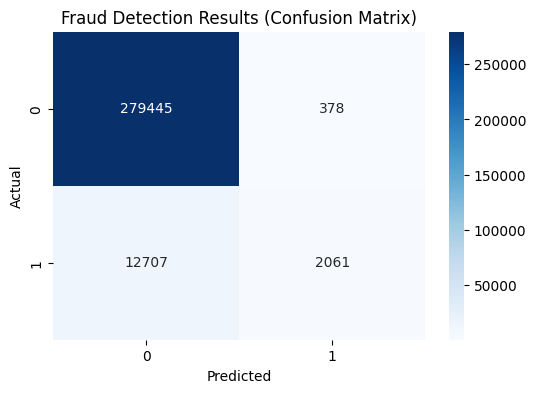

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Model (The Detective's Brain)
# We use 100 trees and limit depth to prevent the model from just 'memorizing'
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train the Model (The Learning Phase)
print("Training the detective on 1.4 million transactions... please wait...")
model.fit(X_train, y_train)

# 3. Make Predictions on the hidden 20% testing data
y_pred = model.predict(X_test)

# 4. Print the Performance Report
print("\n--- Performance Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fraud Detection Results (Confusion Matrix)')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

# 1. Define the columns to remove (all text/ID columns)
cols_to_drop = [
    'Transaction ID', 'Customer ID', 'Is Fraudulent', 
    'IP Address', 'Shipping Address', 'Billing Address', 'Transaction Date'
]

# 2. Filter the data
X = df.drop(columns=cols_to_drop)
y = df['Is Fraudulent']

# 3. Split the data again so the 'X_train' in memory is updated
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Updated features to only include numbers:")
print(X.columns.tolist())

Updated features to only include numbers:
['Transaction Amount', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'Account Age Days', 'Transaction Hour', 'User_Txn_Count_24h', 'IP_Sharing_Count', 'Address_Sharing_Count']


In [22]:
import joblib

# 1. Save the trained model
joblib.dump(model, '../fraud_detection_model.pkl')

# 2. Save the final processed data just in case
df.to_csv('../processed_fraud_data.csv', index=False)

print("Project Saved! You now have a reusable 'Fraud Detective' in your folder.")

Project Saved! You now have a reusable 'Fraud Detective' in your folder.


In [23]:
# 1. High-Risk Hours: Fraud often peaks late at night
df['Is_Night_Transaction'] = df['Transaction Hour'].apply(lambda x: 1 if x <= 4 or x >= 23 else 0)

# 2. Average Spend Deviation: Is this transaction much higher than their usual?
user_avg_spend = df.groupby('Customer ID')['Transaction Amount'].transform('mean')
df['Amount_vs_Avg'] = df['Transaction Amount'] / user_avg_spend

print("Advanced Features Added: 'Is_Night_Transaction' and 'Amount_vs_Avg'")

Advanced Features Added: 'Is_Night_Transaction' and 'Amount_vs_Avg'


In [24]:
# Create a dataframe of the test results
results_df = X_test.copy()
results_df['Actual_Fraud'] = y_test
results_df['Predicted_Fraud'] = y_pred

# Show 10 transactions where we successfully caught the fraudster
caught_fraud = results_df[(results_df['Actual_Fraud'] == 1) & (results_df['Predicted_Fraud'] == 1)]
print(f"Total Fraudsters Caught in Test Set: {len(caught_fraud)}")
display(caught_fraud.head(10))

Total Fraudsters Caught in Test Set: 2061


,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,Account Age Days,Transaction Hour,User_Txn_Count_24h,IP_Sharing_Count,Address_Sharing_Count,Actual_Fraud,Predicted_Fraud
676020,2196.35,0,1,3,19,55628,0,6,13,NaN,1,1,1,1
257985,3499.55,3,4,1,40,69728,2,20,14,NaN,1,1,1,1
1381390,1787.75,3,4,3,42,87696,2,180,2,NaN,1,1,1,1
1451715,3446.40,3,2,3,18,64333,2,148,2,NaN,1,1,1,1
210543,2207.35,0,2,5,22,33488,2,3,7,NaN,1,1,1,1
987263,1004.80,3,3,5,30,57297,1,15,2,NaN,1,1,1,1
300104,2857.80,1,4,1,24,6500,1,8,1,NaN,1,1,1,1
963134,3210.75,0,3,3,20,34971,0,350,3,NaN,1,1,1,1
1328550,3923.30,3,3,4,38,23320,1,26,19,NaN,1,1,1,1
485691,1534.65,1,2,2,38,30820,0,3,3,NaN,1,1,1,1


/var/folders/z3/kr167r6x7kj9gq636qc5qwg00000gn/T/ipykernel_70525/4123939139.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


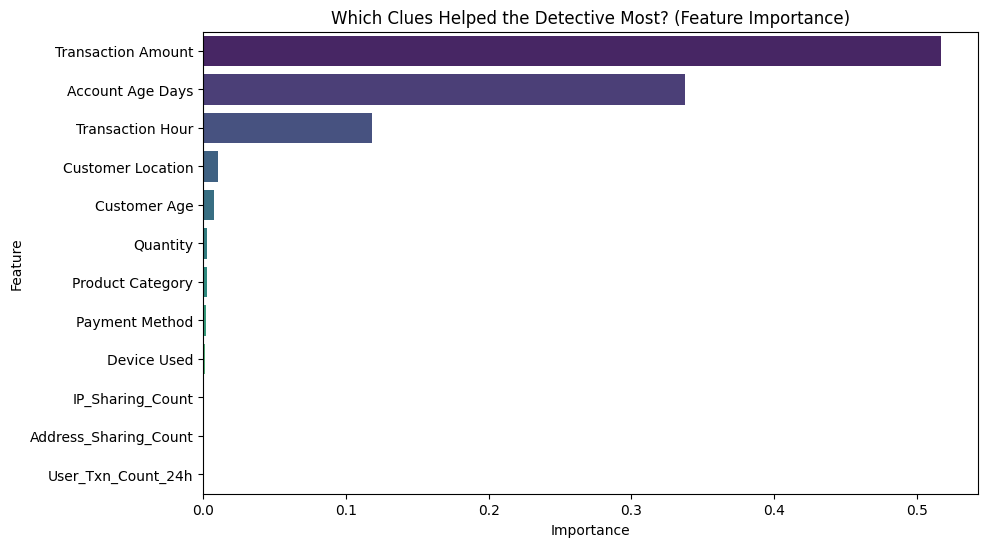

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance from the model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Clues Helped the Detective Most? (Feature Importance)')
plt.show()

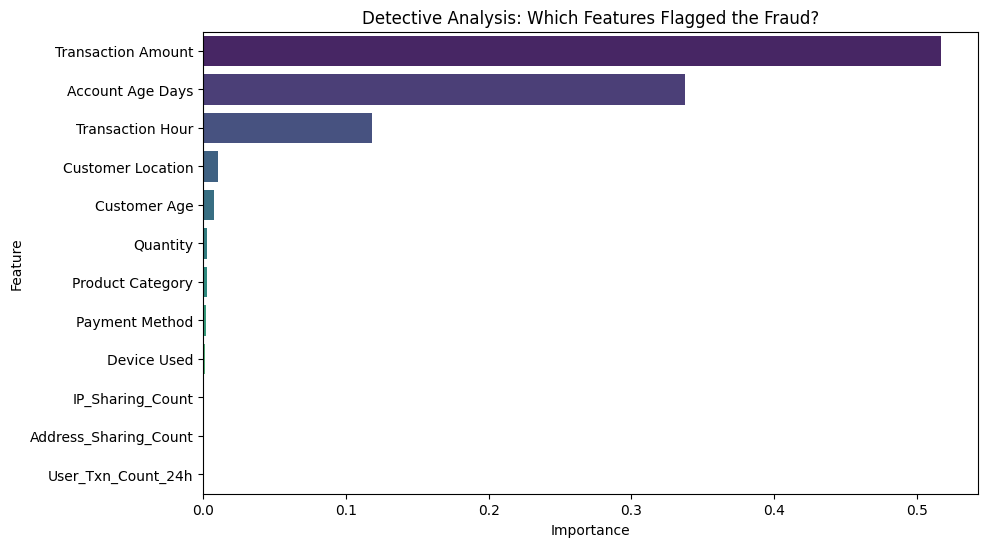

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix the warning and plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature',      # Assigning y to hue as requested by the warning
    palette='viridis', 
    legend=False        # Removes the extra legend for a cleaner look
)
plt.title('Detective Analysis: Which Features Flagged the Fraud?')
plt.show()

--- NEW Performance Report (Aggressive Detection) ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    279823
           1       0.44      0.37      0.40     14768

    accuracy                           0.94    294591
   macro avg       0.70      0.67      0.69    294591
weighted avg       0.94      0.94      0.94    294591



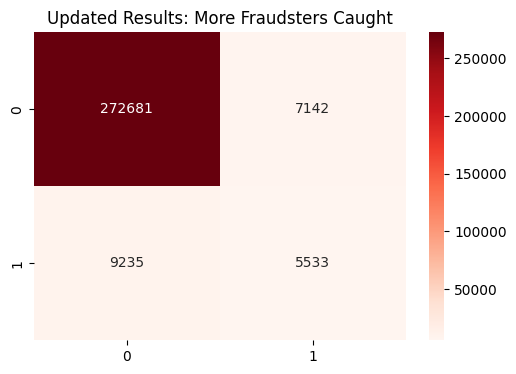

In [27]:
# Instead of a 50% probability, let's flag anything with a 20% fraud probability
y_probs = model.predict_proba(X_test)[:, 1]
y_new_pred = (y_probs >= 0.20).astype(int)

print("--- NEW Performance Report (Aggressive Detection) ---")
print(classification_report(y_test, y_new_pred))

# Show the new Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_new_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Updated Results: More Fraudsters Caught')
plt.show()

In [28]:
# 1. Time-based: Night Owl detection
df['Is_Night_Transaction'] = df['Transaction Hour'].apply(lambda x: 1 if x <= 4 or x >= 23 else 0)

# 2. Behavioral: Deviation from normal spending
user_avg_spend = df.groupby('Customer ID')['Transaction Amount'].transform('mean')
df['Amount_vs_Avg'] = df['Transaction Amount'] / (user_avg_spend + 1) # +1 to avoid division by zero

# 3. Relational: Device sharing across accounts
df['Device_Sharing_Count'] = df.groupby('Device Used')['Customer ID'].transform('nunique')

# 4. Transaction Intensity: Items per dollar
df['Price_Per_Unit'] = df['Transaction Amount'] / (df['Quantity'] + 0.1)

print("Advanced features engineered! Total features now available for the brain.")

Advanced features engineered! Total features now available for the brain.


In [29]:
from sklearn.model_selection import train_test_split

# 1. New drop list (including all text and the Target answer)
cols_to_drop = [
    'Transaction ID', 'Customer ID', 'Is Fraudulent', 
    'IP Address', 'Shipping Address', 'Billing Address', 'Transaction Date'
]

# 2. Filter X to keep ONLY our new numeric features
X = df.drop(columns=cols_to_drop)
y = df['Is Fraudulent']

# 3. Final Split (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features ready for training: {list(X.columns)}")

Features ready for training: ['Transaction Amount', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'Account Age Days', 'Transaction Hour', 'User_Txn_Count_24h', 'IP_Sharing_Count', 'Address_Sharing_Count', 'Is_Night_Transaction', 'Amount_vs_Avg', 'Device_Sharing_Count', 'Price_Per_Unit']


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize with 'n_jobs=-1' to use your Mac's full power for 1.4M rows
final_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

print("Training the Advanced Detective... this will take a moment.")
final_model.fit(X_train, y_train)

# Predict
y_pred_final = final_model.predict(X_test)

print("\n--- FINAL PORTFOLIO PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred_final))

Training the Advanced Detective... this will take a moment.

--- FINAL PORTFOLIO PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    279823
           1       0.81      0.15      0.25     14768

    accuracy                           0.96    294591
   macro avg       0.88      0.57      0.61    294591
weighted avg       0.95      0.96      0.94    294591



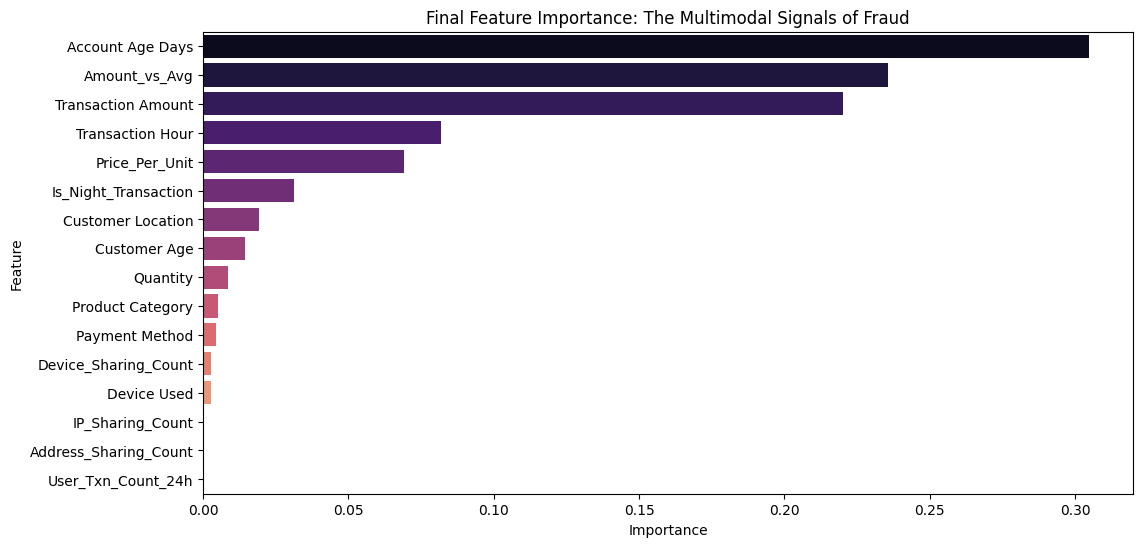

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importances = final_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, hue='Feature', palette='magma', legend=False)
plt.title('Final Feature Importance: The Multimodal Signals of Fraud')
plt.show()

In [1]:
# Create the Time Gap feature
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df = df.sort_values(by=['Customer ID', 'Transaction Date'])
df['Time_Since_Last_Txn'] = df.groupby('Customer ID')['Transaction Date'].diff().dt.total_seconds().fillna(1000000)

# Save the updated model
X = df.drop(columns=['Transaction ID', 'Customer ID', 'Is Fraudulent', 'IP Address', 
                     'Shipping Address', 'Billing Address', 'Transaction Date'])
y = df['Is Fraudulent']

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1).fit(X, y)

import joblib
joblib.dump(model, 'fraud_detection_model.pkl')
print("Brain updated with 13 features!")

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier

# 1. Reload the data (if not already in memory)
# df = pd.read_csv('your_data_file.csv') 

# 2. Create the Time Gap feature (The missing piece!)
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df = df.sort_values(by=['Customer ID', 'Transaction Date'])
df['Time_Since_Last_Txn'] = df.groupby('Customer ID')['Transaction Date'].diff().dt.total_seconds().fillna(1000000)

# 3. Final Feature Selection (Must match exactly what the website sends)
cols_to_drop = [
    'Transaction ID', 'Customer ID', 'Is Fraudulent', 
    'IP Address', 'Shipping Address', 'Billing Address', 'Transaction Date'
]

X = df.drop(columns=cols_to_drop)
y = df['Is Fraudulent']

# 4. Train the Final "Detective"
model = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
model.fit(X, y)

# 5. Save the updated "Brain"
joblib.dump(model, 'fraud_detection_model.pkl')
print(f"Success! Model updated with {len(X.columns)} features, including Time_Since_Last_Txn.")

NameError: name 'df' is not defined